In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### **Exercise 1**: Lab1_3: finite-differences with tolerance **Jacobi method**


SOlve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
2. Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.

In [2]:
# Solver LAPLACE Equation:

def solve_laplace_tol_vec(u_0, x, y, tol=1e-6, max_iter=100_000):
    
    u = u_0.copy() 
    u_new = u.copy() 
  
    X, Y = np.meshgrid(x, y) 
    for k in range(max_iter): 
        u_new[1:-1, 1:-1] = 0.25 * ( u[2:, 1:-1] + # abajo 
                                    u[:-2, 1:-1] + # arriba 
                                    u[1:-1, 2: ] + # derecha 
                                    u[1:-1, :-2 ] # izquierda 
                                    ) 
        if np.linalg.norm(u_new - u, ord=np.inf) < tol: 
            print(f"Convergencia alcanzada en {k} iteraciones.") 
            return X, Y, u_new 
        u, u_new = u_new, u
         
    print("No se alcanzó la convergencia dentro del número máximo de iteraciones.") 
    return X, Y, u

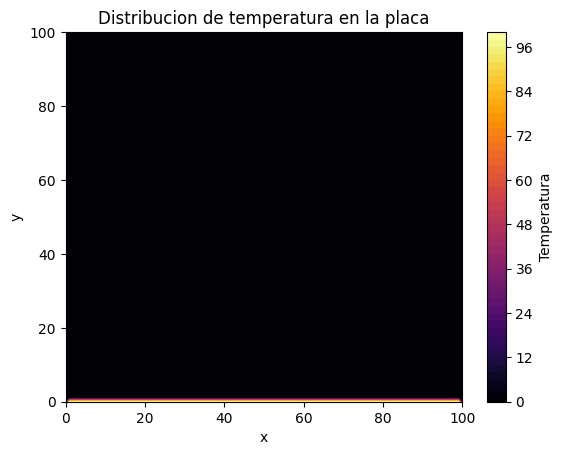

In [3]:
# Campo de prueba --> condiciones iniciales y de frontera

N = 100  # Numero de puntos en cada direccion
L = 100  # Longitud

D = L / N  # Tamano del paso

u = np.zeros((N, N), dtype=float)

# Condiciones de frontera:
# u(x,0)=100 (borde inferior) y u=0 en los otros bordes.
# Para ser consistente con la serie de Fourier, dejamos las esquinas en 0.
u[0, 1:-1] = 100

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)

plt.contourf(X, Y, u, levels=50, cmap='inferno')
plt.colorbar(label='Temperatura')
plt.title('Distribucion de temperatura en la placa')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Convergencia alcanzada en 14216 iteraciones.


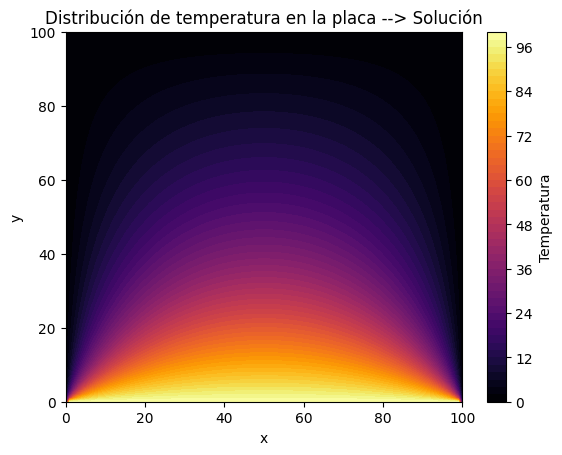

In [4]:
# Visualización de la solución para tolerancia de 1e-3

X,Y, U = solve_laplace_tol_vec(u, x, y, tol=1e-3)

plt.contourf(X, Y, U, levels=50, cmap='inferno')
plt.colorbar(label='Temperatura')
plt.title('Distribución de temperatura en la placa --> Solución')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

BIEN... No deberian ser tantos términos. son del orden de 100... CALCULAR EL ERROR RELATIVO~tol

La estrategia para la solución de la EDP se basa en reemplazar las segundas derivadas parciales empleando los terminos $\pm\Delta$ en las series de Taylor del campo $U(x,y)$. En clase se mostro que la expresión del campo debe estar dada por la expresión:

\begin{equation*}
u(x,y) = \dfrac{1}{4} \left( u(x+\Delta,y)+u(x-\Delta,y) + u(x, y+\Delta)+u(x,y-\Delta)\right)
\end{equation*}

Al discretizar esta ecuación y dejarlo en termino de indices matriciales (algo que un computador puede procesar), obtenemos la expresión:

\begin{equation*}
u_{i,j} = \dfrac{1}{4} \big[ u_{i+1,j}+u_{i-1,j} +u_{i,j+1}+u_{i,j-1} \big]
\end{equation*}

Ahora en teoria esta condición debe cumplirse para la función, cuyas condiciones de frontera son conocidas, pero una condiciones de frontera impĺica ademas unicidad en la solución, así que como estrategia partiremos de un campo $u_0(x,y)$ que cumpla con las conidciones de frontera, y ahora cambiaremos sus valores internos empelando la ecuación discreta $u_{i,j}$, este algoritmo lo repetiremos muchas veces, dada la unicidad de la solución, estas actualizaciones constantes convergeran a la solución real.

En particular yo use una solución de tipo Jacobi, donde la suma no se hace paso a paso si no que cada ciclo es inmediato, para python esto es conveniente, pero númericamente requiere mas ciclos para converger

Empleando el método de separación de variables, e imponiendo las condiciones de frontera, se puede obtener una solución analítica como una serie de Fouerier del siguiente tipo

\begin{equation*}
u(x,y) = \sum_{n=1}^{ \infty } \frac{4 V_0}{(2n-1)\pi \sinh{((2n-1)\pi)}} \sin{\left( \frac{(2n-1)\pi}{L} x \right)} \sinh{\left( \frac{(2n-1)\pi}{L} (L-y) \right)}
\end{equation*} 

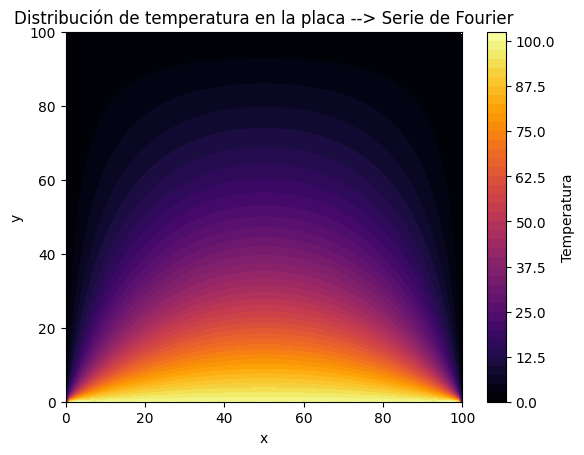

In [5]:
def serie_fourier2(X, Y, L, V0=100, n_terms=100):

    n = 2 * np.arange(1, n_terms + 1) - 1  
    n = np.ones_like(X) * n[:, None, None]  

    U = np.sum(
        (4 * V0) / (n * np.pi * np.sinh(n * np.pi))
        * np.sin((n * np.pi / L) * X[None])
        * np.sinh((n * np.pi / L) * (L - Y[None])),
        axis=0
    )
    return U

# Ejemplo con las variables ya existentes:
U_fourier_formula = serie_fourier2(X, Y, L, V0=100, n_terms=112)
plt.contourf(X, Y, U_fourier_formula, levels=50, cmap='inferno')
plt.colorbar(label='Temperatura')
plt.title('Distribución de temperatura en la placa --> Serie de Fourier')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Me esta dando problemas de overflow para n grandes ($n \geq 112$)

BIEN...NO SON 50 TERMINOS. SON ALREDEDOR DE 11... ES POR LA FORMA QUE CALCULAS EL ERROR. NOTA: 5.0

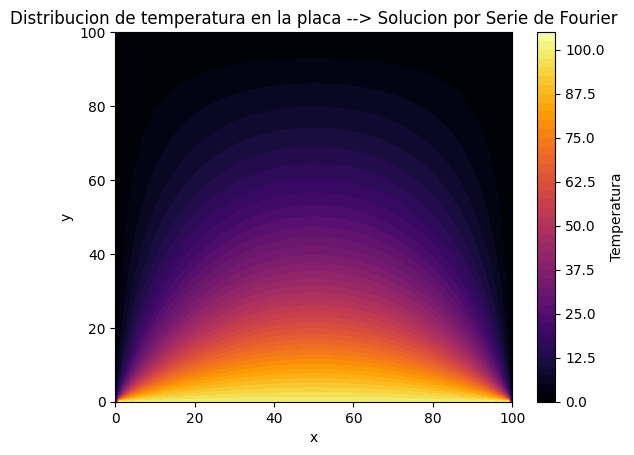

In [6]:
def serie_fourier(x, y, L, tol=1e-3, max_terms=1000):
    # Acepta x,y 1D (preferido) o mallas 2D.
    if np.ndim(x) == 2:
        x_vec = x[0, :]
    else:
        x_vec = x

    if np.ndim(y) == 2:
        y_vec = y[:, 0]
    else:
        y_vec = y

    Xf, Yf = np.meshgrid(x_vec, y_vec)
    u = np.zeros_like(Xf, dtype=float)

    # Malla auxiliar para evaluar error global y evitar aliasing.
    x_check = np.linspace(0, L, 4 * len(x_vec) + 1)
    y_check = y_vec
    Xc, Yc = np.meshgrid(x_check, y_check)
    u_check = np.zeros_like(Xc, dtype=float)

    for n in range(1, max_terms + 1, 2):
        ratio_f = (
            np.exp(-n * np.pi * Yf / L)
            * (1 - np.exp(-2 * n * np.pi * (L - Yf) / L))
            / (1 - np.exp(-2 * n * np.pi))
        )
        ratio_c = (
            np.exp(-n * np.pi * Yc / L)
            * (1 - np.exp(-2 * n * np.pi * (L - Yc) / L))
            / (1 - np.exp(-2 * n * np.pi))
        )

        u_n = (400 / (n * np.pi)) * np.sin(n * np.pi * Xf / L) * ratio_f
        u_n_check = (400 / (n * np.pi)) * np.sin(n * np.pi * Xc / L) * ratio_c

        u += u_n
        u_check_new = u_check + u_n_check

        # Opcion 3: error global entre sumas parciales consecutivas.
        err_global = np.mean(np.abs(u_check_new - u_check))
        u_check = u_check_new

        if err_global < tol:
            print(f"Convergencia alcanzada en n={n} terminos (error global={err_global:.3e}).")
            break

    return u

U_fourier = serie_fourier(x, y, L, tol=1e-3, max_terms=501)

plt.contourf(X, Y, U_fourier, levels=50, cmap='inferno')
plt.colorbar(label='Temperatura')
plt.title('Distribucion de temperatura en la placa --> Solucion por Serie de Fourier')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Notemos que la solución converge con una tolerancia de $10^{-3}$ con los primeros 99 términos de la serie

In [7]:
# Comparacion numerica limpia (evita imprimir matrices enormes)
diff = U - U_fourier
print('max abs diff (todo el dominio):', np.max(np.abs(diff)))
print('mean abs diff (todo el dominio):', np.mean(np.abs(diff)))
print('max abs diff (interior):', np.max(np.abs(diff[1:-1, 1:-1])))

max abs diff (todo el dominio): 3.9234267387167137
mean abs diff (todo el dominio): 0.01742077481868285
max abs diff (interior): 0.718069883520883


In [8]:
# Diagnostico: sensibilidad de convergencia a la tolerancia (sin graficas)

def jacobi_iters_for_tol(u_0, tol=1e-6, max_iter=100_000):
    u = u_0.copy()
    u_new = u.copy()
    for k in range(max_iter):
        u_new[1:-1, 1:-1] = 0.25 * (
            u[2:, 1:-1] + u[:-2, 1:-1] + u[1:-1, 2:] + u[1:-1, :-2]
        )
        if np.linalg.norm(u_new - u, ord=np.inf) < tol:
            return k
        u, u_new = u_new, u
    return max_iter


def fourier_n_for_tol(x, y, L, tol=1e-3, max_terms=20_000):
    Xf, Yf = np.meshgrid(x, y)

    x_check = np.linspace(0, L, 4 * len(x) + 1)
    y_check = y
    Xc, Yc = np.meshgrid(x_check, y_check)
    u_check = np.zeros_like(Xc, dtype=float)

    for n in range(1, max_terms + 1, 2):
        ratio_f = (
            np.exp(-n * np.pi * Yf / L)
            * (1 - np.exp(-2 * n * np.pi * (L - Yf) / L))
            / (1 - np.exp(-2 * n * np.pi))
        )
        ratio_c = (
            np.exp(-n * np.pi * Yc / L)
            * (1 - np.exp(-2 * n * np.pi * (L - Yc) / L))
            / (1 - np.exp(-2 * n * np.pi))
        )

        u_n_check = (400 / (n * np.pi)) * np.sin(n * np.pi * Xc / L) * ratio_c
        u_check_new = u_check + u_n_check
        err_global = np.mean(np.abs(u_check_new - u_check))
        u_check = u_check_new

        if err_global < tol:
            return n

    return max_terms


for t in [1e-1, 1e-2, 1e-3, 1e-6]:
    print(f"tol={t:>8.0e} | Jacobi iters={jacobi_iters_for_tol(u, tol=t):>6} | Fourier n={fourier_n_for_tol(x, y, L, tol=t):>4}")

tol=   1e-01 | Jacobi iters=  5079 | Fourier n=  19
tol=   1e-02 | Jacobi iters=  9644 | Fourier n=  87
tol=   1e-03 | Jacobi iters= 14216 | Fourier n= 809
tol=   1e-06 | Jacobi iters= 27934 | Fourier n=20000


Para esta última parte del código me ayuda del agente codex incluido en gpt 5.3 copilot, esto pues estaba teniendo problemas con la convergencia de la serie. En particular note que para una tolerancia de $10^{-3}$ se requirieron de los primeros 809 terminos de la serie (Es decir que la convergencia fue mucho más rapida que para el metodo de diferencias finitas). Ahora bien, parece ser que la serie tiene problemas para converger con tolerancias aún menores, de donde se dispara el numero de terminos requeridos. 

#### **Exercise 2**: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


La solución analítica del problema se establece como

\begin{equation*}
    u(x,y) = u_0 \sin{ \left( \frac{2\pi x}{L} \right) } \exp{ \left( - \frac{2\pi y}{L} \right) }
\end{equation*}

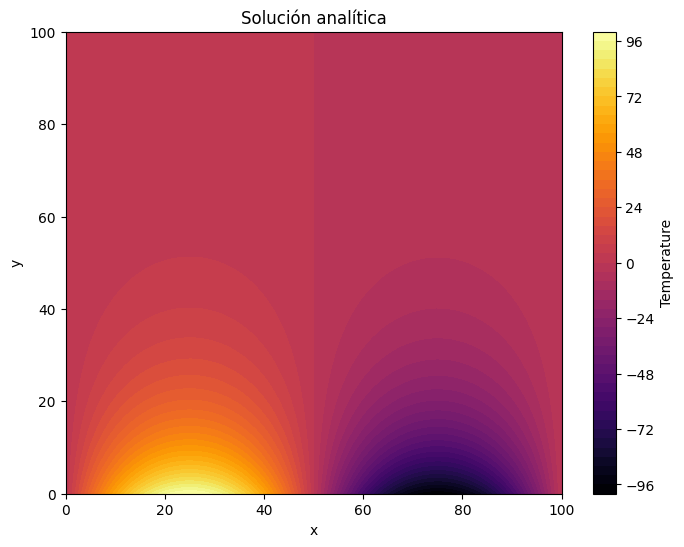

In [9]:
L = 100
u_0 = 100

x = np.linspace(0, L, 100)
y = x

X, Y = np.meshgrid(x, y)
U_analitic = u_0 * np.sin(np.pi * 2 * X / L) * np.exp(- np.pi * 2 * Y / L)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, U_analitic, levels=50, cmap='inferno')
plt.colorbar(label='Temperature')
plt.title('Solución analítica')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

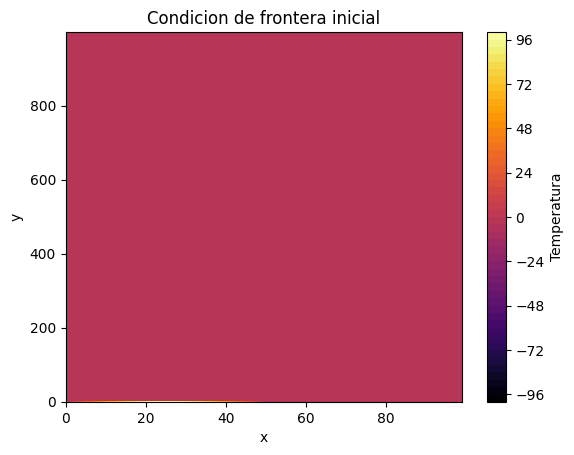

In [10]:
L = 100
N = 100
dx = L / N# Solver LAPLACE Equation:

def solve_laplace_tol_vec(u_0, x, y, tol=1e-6, max_iter=100_000):
    
    u = u_0.copy() 
    u_new = u.copy() 
  
    X, Y = np.meshgrid(x, y) 
    for k in range(max_iter): 
        u_new[1:-1, 1:-1] = 0.25 * ( u[2:, 1:-1] + # abajo 
                                    u[:-2, 1:-1] + # arriba 
                                    u[1:-1, 2: ] + # derecha 
                                    u[1:-1, :-2 ] # izquierda 
                                    ) 
        if np.linalg.norm(u_new - u, ord=np.inf) < tol: 
            print(f"Convergencia alcanzada en {k} iteraciones.") 
            return X, Y, u_new 
        u, u_new = u_new, u
         
    print("No se alcanzó la convergencia dentro del número máximo de iteraciones.") 
    return X, Y, u

u0 = 100

M = 10  # --> Proporcion entre Ly y Lx
Ly = M * L

def f(x):
    return u0 * np.sin(2 * np.pi * x / L)

# Forma de la malla: (ny, nx) = (N*M, N)
# para ser consistente con X, Y = np.meshgrid(x, y)
U_0 = np.zeros((N * M, N))
U_0[0, :] = f(np.linspace(0, L, N))

plt.contourf(U_0, levels=50, cmap='inferno')
plt.colorbar(label='Temperatura')
plt.title('Condicion de frontera inicial')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Nuestra intuición física nos permite entender que la solución en dirección del eje y debe de ser una exponencial negativa, de modo que decae a cero en el infinito, pero el hecho de que su comportamiento sea exponencial implica que decae rápido, de modo que por haora aproximaremos la solución a una maya $L_x \times L_y$ tal que sea $L_x \times N L_x$ con $N$ puede ser 5 o 6, y haremos que la solución sea cero en ese borde (Un corte abrupto en la simulación)

In [11]:
# Solver LAPLACE Equation:

def solve_laplace_tol_vec(u_0, x, y, tol=1e-12, max_iter=100_000):
    
    u = u_0.copy() 
    u_new = u.copy() 
  
    X, Y = np.meshgrid(x, y) 
    for k in range(max_iter): 
        u_new[1:-1, 1:-1] = 0.25 * ( u[2:, 1:-1] + # abajo 
                                    u[:-2, 1:-1] + # arriba 
                                    u[1:-1, 2: ] + # derecha 
                                    u[1:-1, :-2 ] # izquierda 
                                    ) 
        if np.linalg.norm(u_new - u, ord=np.inf) < tol: 
            print(f"Convergencia alcanzada en {k} iteraciones.") 
            return X, Y, u_new 
        u, u_new = u_new, u
         
    print("No se alcanzó la convergencia dentro del número máximo de iteraciones.") 
    return X, Y, u

Convergencia alcanzada en 24670 iteraciones.


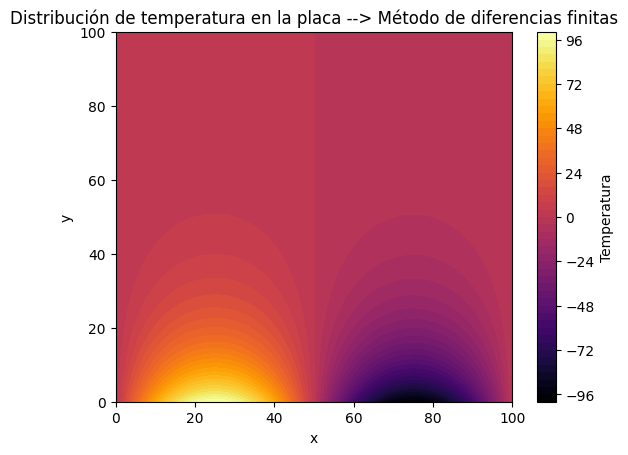

In [14]:
x = np.linspace(0, L, N)
y = np.linspace(0, Ly, N * M)

X, Y, U = solve_laplace_tol_vec(U_0, x, y)

plt.contourf(X, Y, U, levels=50, cmap='inferno')
plt.colorbar(label='Temperatura')
plt.title('Distribución de temperatura en la placa --> Método de diferencias finitas')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(0, L)  # Ajustar límites del eje y para mostrar toda la placa
plt.show()

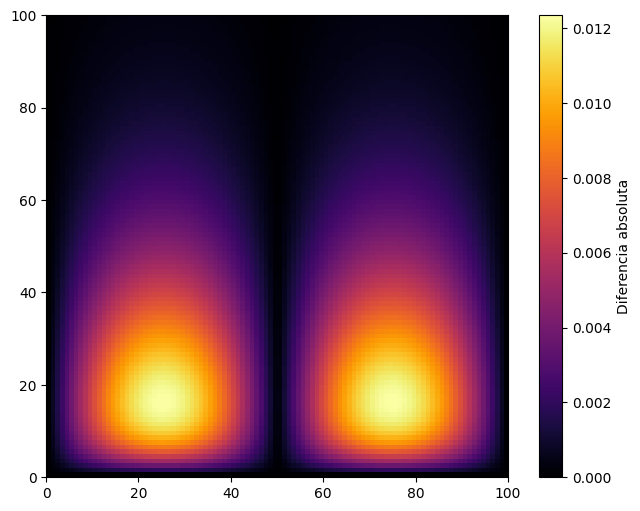

In [15]:
diff = np.abs(U[:100,:] - U_analitic)
plt.figure(figsize=(8, 6))
plt.imshow(diff, extent=(0, L, 0, L), origin='lower', cmap='inferno')
plt.colorbar(label='Diferencia absoluta')    

NOTA 5.0 revisar la forma de calcular el error relativos o la tolerancia